# **Notebook 1: Exploratory Data Analysis (EDA)**


> **Objective:** Perform initial data profiling on the raw data to justify our preprocessing decisions and to uncover actionable business insights and guide Machine Learning feature selection.
The Exploratory Analysis section of this notebook aims at obtaining the most information about our data to better judge what techniques will be required regarding the possibility of missing values and outliers as well as what transformations will be made to the data to improve its usability.


---

## **Table of Contents**
1. **Imports and Libraries**
2. **Customer Dataset EDA**
    - 2.1 **Structural Overview**
        - 2.1.1 **Datatypes**
    - 2.2 **Missing Values Analysis**
    - 2.3 **Variables Distribution**
    - 2.4 **Heat Map and Check Correlations**
    - 2.5 **Geo Analysis**
3. **Basket Dataset EDA**
    - 3.1 **Structural Overview**
        - 3.1.1 **Datatypes**
    - 3.2 **Basket Size Analysis**
        - 3.2.1 **Top Products**
    - 3.3 **Missing Values Analysis**
    - 3.4 **Variables Distribution**
    - 3.5 **Items Co-Ocurrence**
4. **EDA Summary and Preprocessing Implications**
5. **Bivariate Analysis: Baseline Relationships**
6. **Action Plan for Preprocessing**

---


## **1. Imports and Libraries** <a id="1-imports"></a>


In [22]:
%load_ext autoreload
%autoreload 2

import base64
from IPython.display import IFrame, display

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
import geopandas as gpd
import ast 
from collections import Counter
from mapclassify import classify

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


import sys 
sys.path.append("../src") 

from eda import plot_missing_values, plot_distribution, plot_pie_chart, plot_correlation_matrix, map

# Load the RAW datasets
raw_customer = pd.read_csv('../data/customer_info.csv', index_col=0)
raw_basket = pd.read_csv('../data/customer_basket.csv')

print(f"Raw Customer Shape: {raw_customer.shape}")
print(f"Raw Basket Shape: {raw_basket.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Raw Customer Shape: (33038, 24)
Raw Basket Shape: (100000, 3)


<a id="2-customer-dataset"></a>
## **2. Customer Dataset EDA**

> The first step is to get a **good understanding** of the data we're working with. We will start by analyzing more general information

### **2.1. Structural Overview**

In [23]:
raw_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

In [24]:
raw_customer.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


#### **Observations: Introduction and First Rows**

The intial 5 rows of both datasets confirms that the files were imported correctly, with headers and data properly aligned. 

On the `raw_customer` dataset, we can see that each row represents a different **individual**, its store preferences, demographical information and where they are located.  Regarding the `raw_basket` dataset, things are a little bit different. Now, each records represents a **transaction** instead of a costumer, which means that each customer can have multiple rows assigned to him.

Both datasets share the `customer_id` column, which can later be used to connect transaction-level basket information with the customer segmentation results.

In [25]:
raw_customer.describe().T

,count,mean,std,min,25%,50%,75%,max
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,483.000000,891.250000,3704.000000


In [26]:
raw_customer.describe(include='O').T

,count,unique,top,freq
customer_name,33038,32543,Susan Smith,5
customer_gender,33038,2,female,16577
customer_birthdate,32873,32852,05/19/1973 08:31 AM,2


#### **Observations:**

The summary of the `raw_customer` dataset allows us to have a complete overview of the dataset where we can verify the presence of possible outliers, impossible values and much more.
We can see enormous values in the variable `lifetime_spend_groceries` with 104670 euros spent which probably indicates **outliers**  and we can also see impossible values on the `percentage_of_products_bought_promotion` column which has a negative minimum value which obviously cannot be possible.

#### **2.1.1 Datatypes**

> Identifying these format limitations at this stage provides a clear, structured roadmap for the data cleaning and feature engineering steps that will immediately follow.

In [27]:
raw_customer.dtypes

customer_name                               object
customer_gender                             object
customer_birthdate                          object
kids_home                                  float64
teens_home                                 float64
number_complaints                          float64
distinct_stores_visited                    float64
lifetime_spend_groceries                   float64
lifetime_spend_electronics                 float64
typical_hour                               float64
lifetime_spend_vegetables                  float64
lifetime_spend_nonalcohol_drinks           float64
lifetime_spend_alcohol_drinks              float64
lifetime_spend_meat                        float64
lifetime_spend_fish                        float64
lifetime_spend_hygiene                     float64
lifetime_spend_videogames                  float64
lifetime_spend_petfood                     float64
lifetime_total_distinct_products           float64
percentage_of_products_bought_p

#### **Observations: Data Types** 

The initial inspection of the dataset datatypes reveals that it is currently composed entirely of only `float64`and `str` variables.
The numerical columns represent our continuos variables that are ready for mathematical operations. However, some of them would fit even better with another datatype and require scaling later.

Because machine learning algorithms only rely on mathematical calculations, those variables cannot be a part of that process. This will probably envolve applying encoding techniques or even completely 'ignoring' them for the usage in our model.

<a id="2.2--customer"></a>
## **2.2. Missing Values Analysis**

> Moving on to the missing value analysis

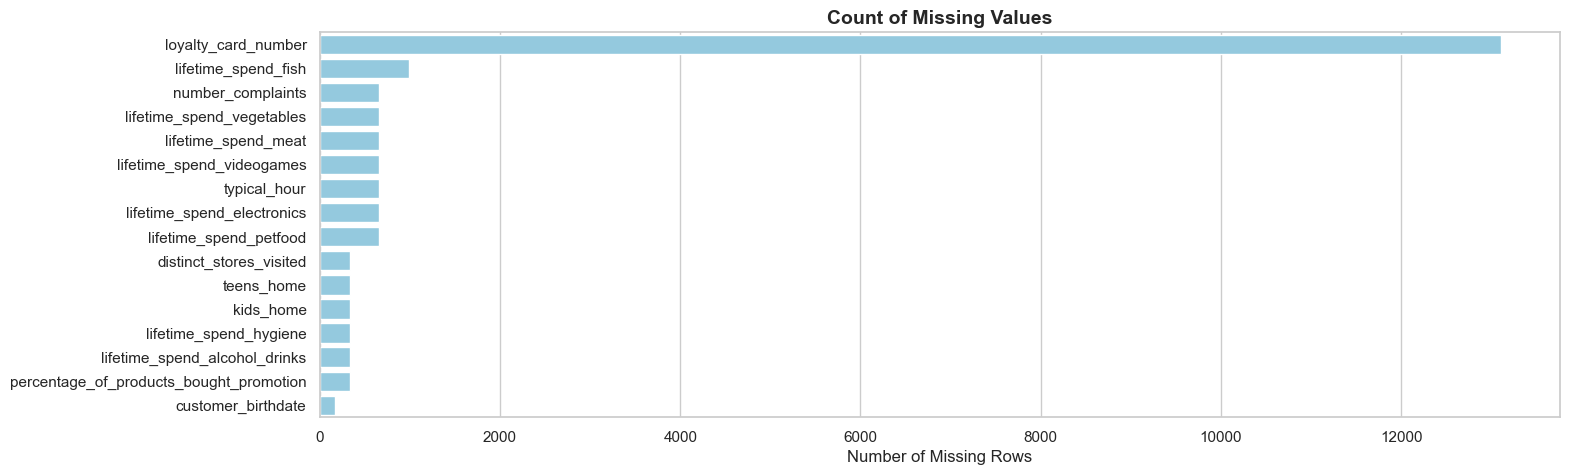

In [28]:
plot_missing_values(raw_customer, 'Count of Missing Values')

#### **Observations:**

This bar chart tells us that 16 of our columns have missing values highlighting the `loyalty_card_number` which has more than 12000 missing values. We will end up dropping that column as it also isn't useful for our models.
We will take care of all those values on the Pre Processing phase.

<a id="2.3-distribution-customer"></a>
## **2.3. Variables Distribution**

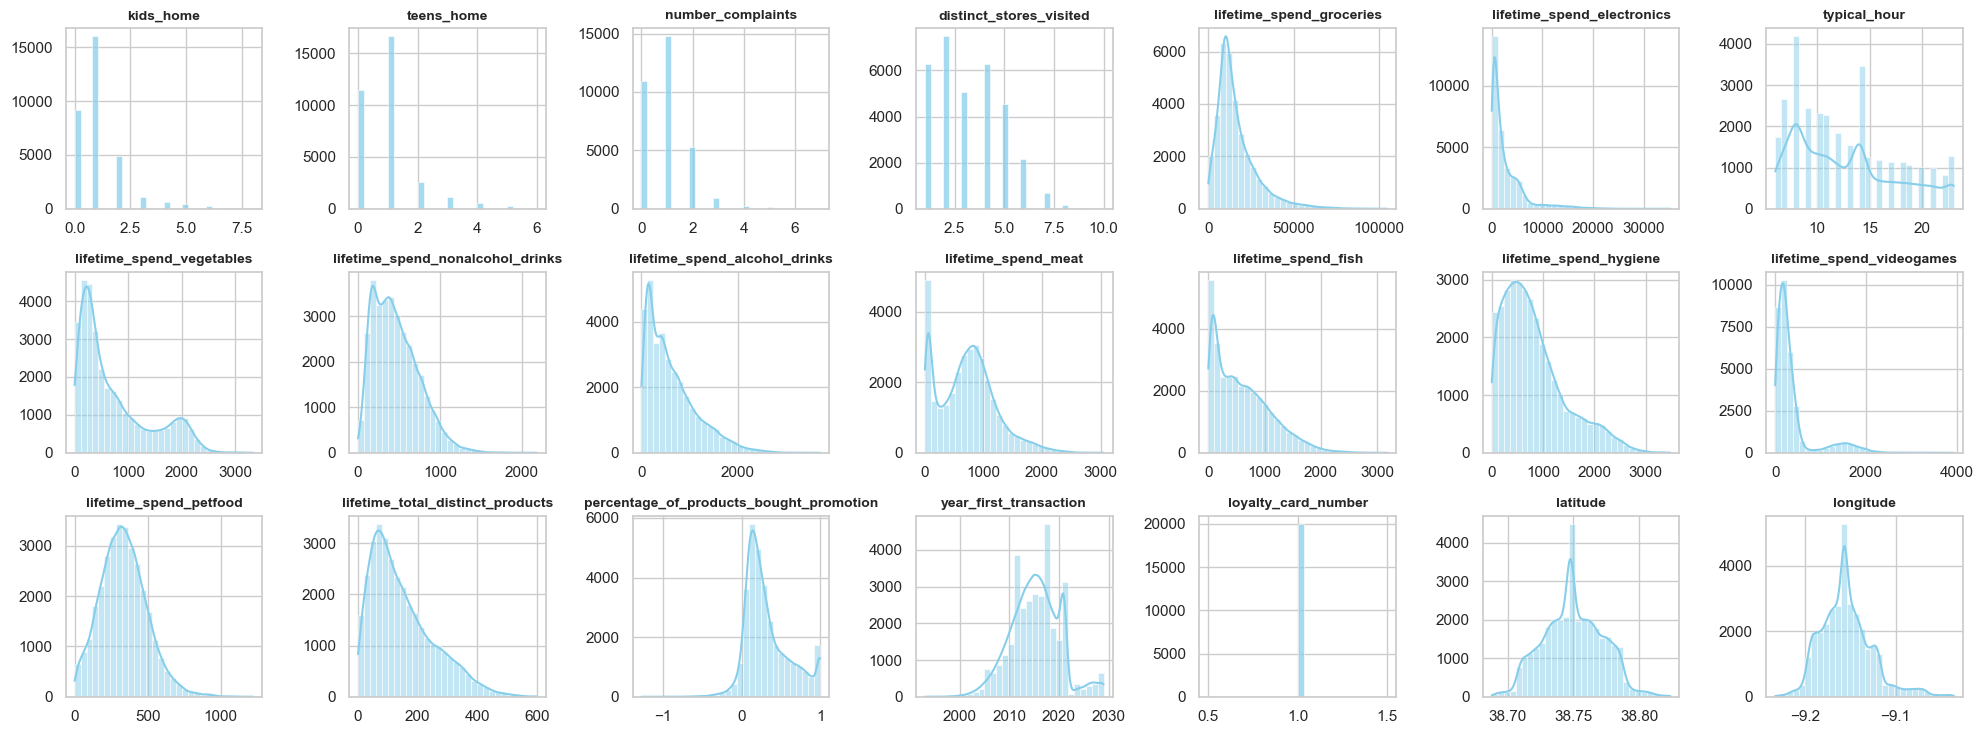

In [29]:
plot_distribution(raw_customer)

#### **Observations: Feature Distributions and Skewness**

The visualizations reveal distinctly different structural patterns across the variables. 
All the `lifetime_spend` variables present a severe right-skewness. They have a massive concentration of record near zero and a long tail of extreme outliers. Consequently, these specific features will require transformation techniques such as **logarithmic scaling** to reduce the disproportionate influence of these extreme outliers.
Regarding the rest, they seem pretty normal we would say.

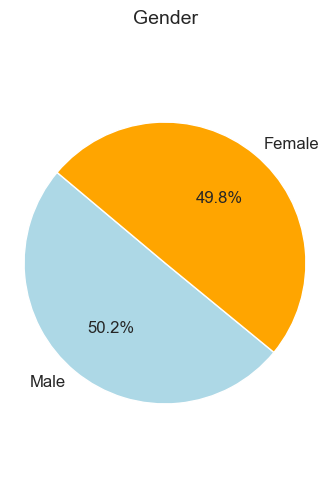

In [30]:
plot_pie_chart(raw_customer, variable='customer_gender', colors=['lightblue', 'orange'], legend=['Male', 'Female'], title_= "Gender")

#### **Observations:**

From the pie chart above we can conclude that our dataset has a nearly **identical distribution** of male and female customers.

<a id="2.4-correlations-customer"></a>
## **2.4. Heat Map and Check Correlations**

> In this section, we will check for highly correlated variables in our data

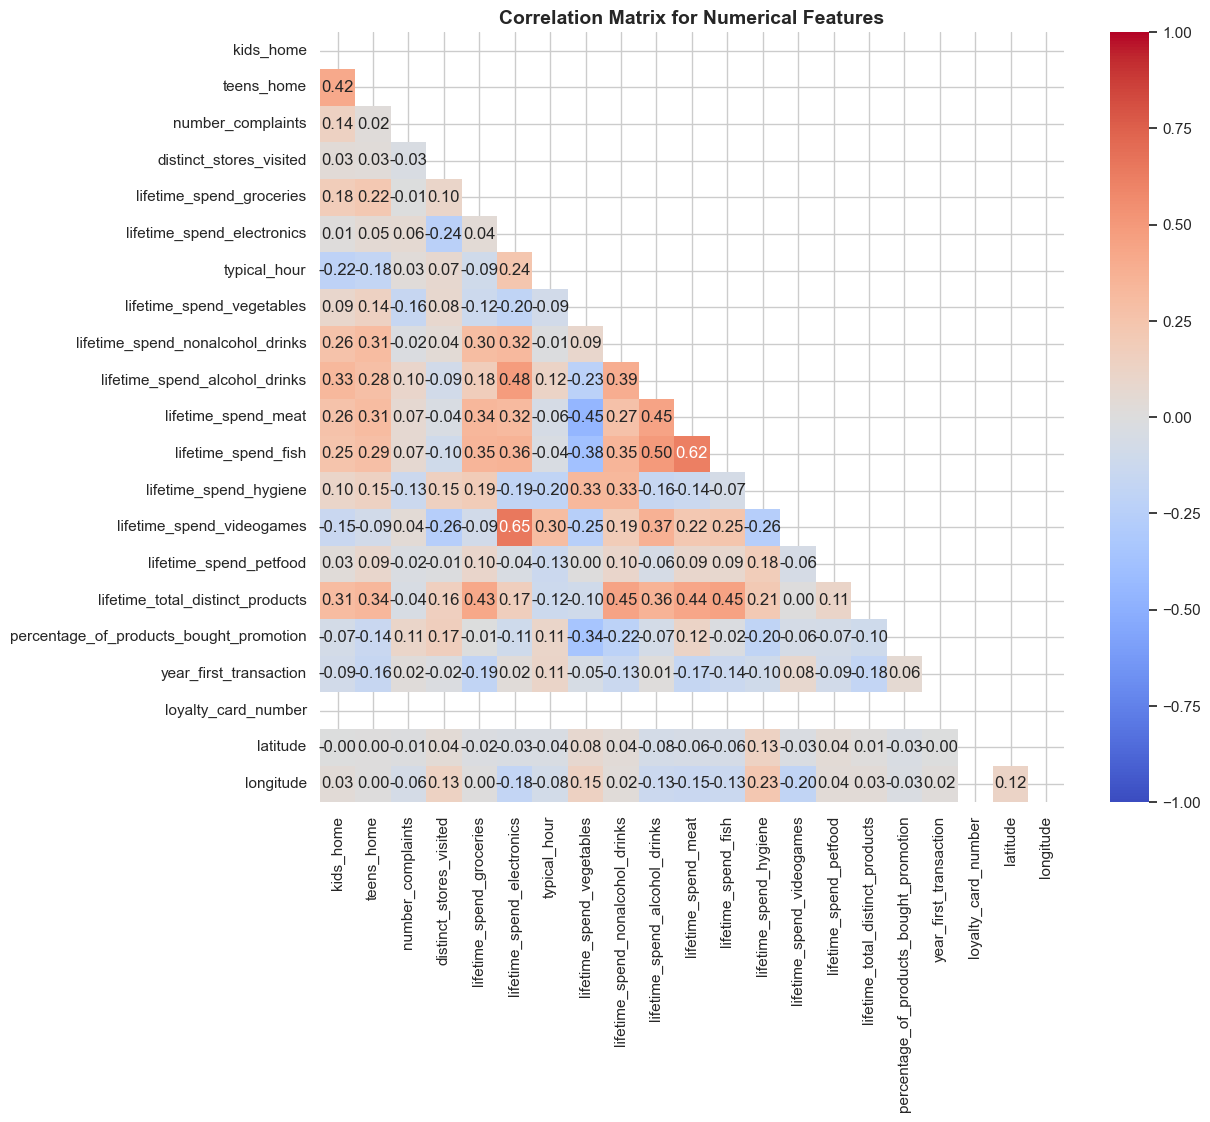

In [31]:
plot_correlation_matrix(raw_customer, title ="Correlation Matrix for Numerical Features")

#### **Observations:**

As we can see above, the highest correlated features are:
- `lifetime_spend_videogames` vs `lifetime_spend_electronics` **(0.65)**
- `lifetime_spend_meat` vs `lifetime_spend_fish` **(0.62)**

This can be explained due to the fact that videogames and electronics in general are linked and, to play videogames one needs, most of the times, some kind of electronic device.
The fish and meat correlation is also predictable because most individuals who eat meat also eat fish if they follow a traditional and regular diet.

Even though they do not have a perfect correlation, there's still correlation and the way we will handle this is by **joining those 2 columns** together creating `lifetime_spend_meat_fish` and `lifetime_spend_videogames_electronics`.


<a id="2.5-geo-customer"></a>
## **2.5. Geo Analysis**

> Moving on to the geo analysis, we will analyse the `latitude`and `longitude` to see where are our clients located.

In [32]:
data_geo = gpd.GeoDataFrame(
    raw_customer, geometry=gpd.points_from_xy(raw_customer.longitude, raw_customer.latitude),
    crs="EPSG:4326"
)

In [33]:
map(data_geo, sample_size=1200, filename="full_dataset_map.html", random_seed=42)

Saving full dataset map to full_dataset_map.html...
Rendering inline map with a sample of 1200 points...


#### **Observations:**
The map we can see above only has 1200 samples for easier visualization. However, we obviously confirmed that mapping it with all the observations would have similar results and that is why we created a file called `full_dataset_map.html` to prove that.

Besides that, we can see that all the observations are in Lisbon. There are observations that seem to be in the middle of Tejo but that is probably because the latitude and longitude have a <1km range.

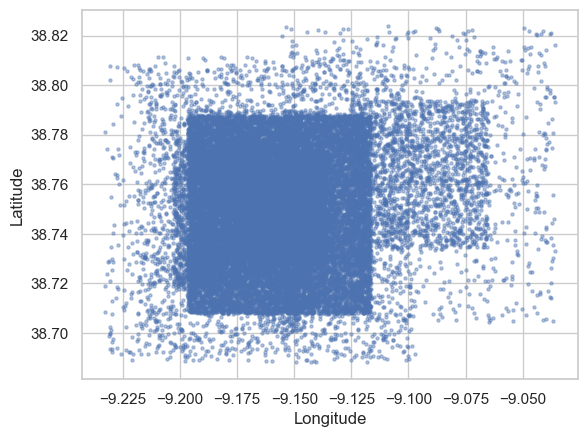

In [58]:
plt.scatter(
    raw_customer["longitude"],
    raw_customer["latitude"],
    s = 5,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

We are doing an iterative process of adjusting xlim and ylim values to find dense group of points.

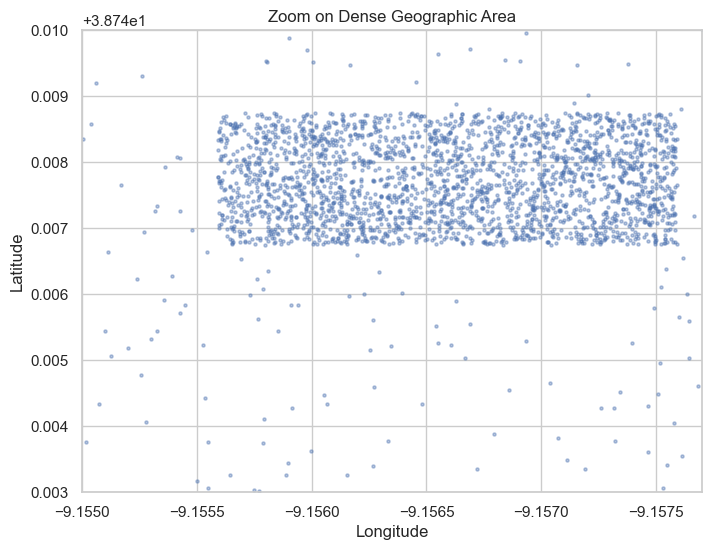

In [59]:
plt.figure(figsize=(8, 6))
plt.scatter(raw_customer['longitude'], raw_customer['latitude'], s=5, alpha=0.4)

plt.ylim(38.743, 38.750)   # latitude
plt.xlim(-9.155, -9.1577)  # longitude

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Zoom on Dense Geographic Area")
plt.show()

In [63]:
geo_eda = raw_customer.copy()

geo_eda['customer_birthdate'] = pd.to_datetime(
    geo_eda['customer_birthdate'],
    errors='coerce',
    format='mixed'
)

geo_eda['customer_age'] = datetime.now().year - geo_eda['customer_birthdate'].dt.year

In [66]:
min_lat = 38.7468
max_lat = 38.7488

min_lon = -9.1576
max_lon = -9.1556




geo_eda["is_dense_geo_area"] = (
    geo_eda["longitude"].between(min_lon, max_lon) &
    geo_eda["latitude"].between(min_lat, max_lat)
).astype(int)

geo_eda["is_dense_geo_area"].value_counts()

is_dense_geo_area
0    30623
1     2415
Name: count, dtype: int64

As we can observe, there are 2415 customers inside the dense group we found on the map!

In [67]:
geo_features = geo_eda.select_dtypes(include='number').columns.tolist()

geo_variability = geo_eda.groupby('is_dense_geo_area')[geo_features].std().round(2).T

geo_cv = (
    geo_eda.groupby('is_dense_geo_area')[geo_features].std() /
    geo_eda.groupby('is_dense_geo_area')[geo_features].mean()
).round(2).T

geo_cv

is_dense_geo_area,0,1
kids_home,1.11,0.21
teens_home,1.06,1.06
number_complaints,1.02,0.25
distinct_stores_visited,0.52,0.36
lifetime_spend_groceries,0.73,0.24
lifetime_spend_electronics,1.22,0.81
typical_hour,0.38,0.22
lifetime_spend_vegetables,0.86,0.65
lifetime_spend_nonalcohol_drinks,0.57,0.53
lifetime_spend_alcohol_drinks,0.86,0.36


Although some spending categories, such as videogames, electronics and hygiene, still show considerable internal variation, the coefficient of variation analysis suggests that customers inside the dense geographic area are relatively homogeneous in several key characteristics, especially age, number of children at home, complaints, grocery spending and store visit behavior. This supports the idea that the dense area is not only a spatial concentration, but also a customer group with a consistent profile.



In [68]:
geo_eda.groupby("is_dense_geo_area")[
    [
        "number_complaints",
        "kids_home",
        "teens_home",
        "distinct_stores_visited",
        "percentage_of_products_bought_promotion",
        "lifetime_spend_groceries",
        "lifetime_spend_vegetables",
        "lifetime_spend_meat",
        "lifetime_spend_fish",
        "lifetime_spend_electronics",
        "lifetime_spend_videogames",
        "lifetime_spend_hygiene",
        "lifetime_spend_alcohol_drinks"
    ]
].mean().T

is_dense_geo_area,0,1
number_complaints,0.841120,2.068441
kids_home,1.043964,2.032245
teens_home,0.925779,0.558295
distinct_stores_visited,3.255863,2.053116
percentage_of_products_bought_promotion,0.305433,0.488961
lifetime_spend_groceries,16794.560069,10114.012836
lifetime_spend_vegetables,767.100850,220.488146
lifetime_spend_meat,739.785226,519.781726
lifetime_spend_fish,623.293215,424.121627
lifetime_spend_electronics,2905.209667,969.269668


**This dense geographic group has a distinct profile and should be further considered during modelling.**


<a id="3-basket-dataset"></a>
## **3. Basket Dataset EDA**

> The first step is to get a **good understanding** of the data we're working with. We will start by analyzing more general information


### **3.1. Structural Overview**

In [69]:
raw_basket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   invoice_id     100000 non-null  int64 
 1   list_of_goods  100000 non-null  object
 2   customer_id    100000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.3+ MB


In [70]:
raw_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [71]:
raw_basket.describe().T

,count,mean,std,min,25%,50%,75%,max
invoice_id,100000.0,6.155483e+06,3.532964e+06,20023.0,3111465.25,6162339.0,9212398.75,12242204.0
customer_id,100000.0,2.003460e+04,1.154614e+04,3.0,10026.00,20018.0,30047.00,40000.0


#### **3.1.1 Datatypes**

In [72]:
raw_basket.dtypes

invoice_id        int64
list_of_goods    object
customer_id       int64
dtype: object


### **3.2. Basket Size Analysis**

In [73]:
basket_eda = raw_basket.copy()
basket_eda["list_of_goods"] = basket_eda["list_of_goods"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
basket_eda["basket_size"] = basket_eda["list_of_goods"].apply(len)

In [74]:
basket_eda["basket_size"].describe()

count    100000.000000
mean          9.399750
std           3.824795
min           1.000000
25%           6.000000
50%           9.000000
75%          12.000000
max          18.000000
Name: basket_size, dtype: float64

**Insights**:
Most customers buy a small number of items per transaction.
Some large baskets exist → potential bulk buyers.


#### **3.2.1. Top Products**

In [16]:
all_items = basket_eda["list_of_goods"].sum()
item_counts = Counter(all_items)

pd.DataFrame(item_counts.most_common(10), columns=["item", "count"])

,item,count
0,asparagus,12811
1,airpods,12145
2,cereals,9952
3,fresh bread,9934
4,butter,9654
5,eggs,9241
6,protein bar,8695
7,cooking oil,8623
8,toilet paper,8395
9,babies food,8318


**Insights**:
- Identified the top10-selling products;
- Likely mix of: groceries (cereals, fresh bread, etc.) and random/non-food items (airpods, electronics).

This suggests that the dataset may simulate mixed retail behavior.

<a id="3-missing-basket"></a>
### **3.3. Missing Values Analysis**

> Moving on to the missing value analysis.

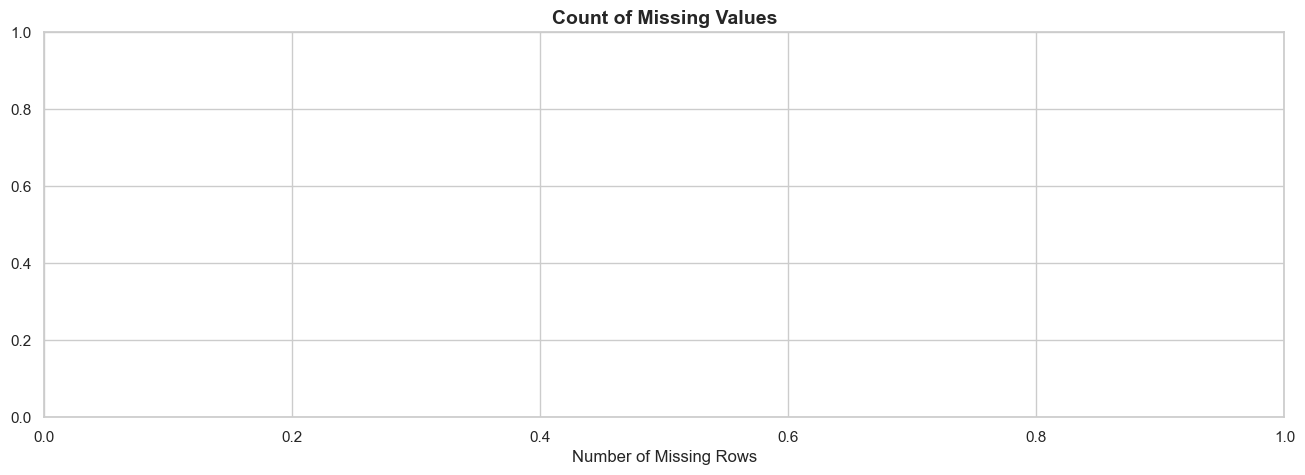

In [75]:
plot_missing_values(basket_eda, 'Count of Missing Values')

In [76]:
basket_eda.isna().sum()

invoice_id       0
list_of_goods    0
customer_id      0
basket_size      0
dtype: int64

#### **Observations:**

As we can see there's no missing values in any of the observations in the customer_basket dataset. Therefore, no need to worry with that!

<a id="3-missing"></a>
### **3.4. Variables Distribution**

We are only going to observe the distribution of basket_size.

<Axes: xlabel='basket_size', ylabel='Count'>

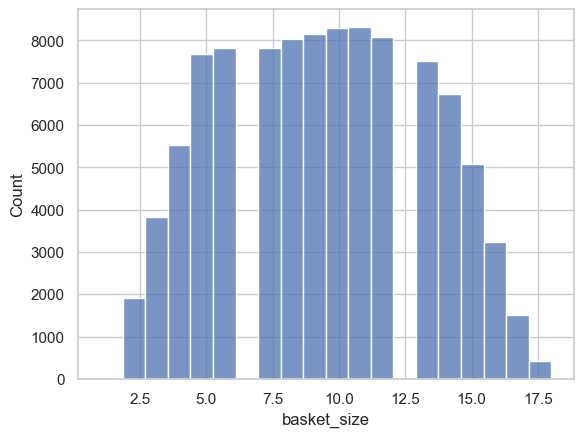

In [19]:
sns.histplot(basket_eda["basket_size"], bins=20)

As we can see it looks like we have a normal distribution regarding the number of items per basket. However we can see that baskets with less size happen more often. This is important for customer segmentation and association rules later on. 

In [78]:
counts_df = pd.DataFrame(item_counts.items(), columns=["item", "count"])

counts_df.set_index("item").plot.pie(
    y="count",
    figsize=(8, 8),
    autopct="%1.1f%%",
    legend=False
)

NameError: name 'item_counts' is not defined

This is a pie chart that works with a frequencie of every single item on each basket. It's a complete mess (expected btw), therefore we created a pie chart with the top15 most purchased items.

Plotting only the top 15 items we have:

In [77]:
top_items = counts_df.nlargest(15, "count")
top_items.set_index("item").plot.pie(y="count", autopct="%1.1f%%")

ax = top_items.set_index("item").plot.pie(
    y="count",
    autopct="%1.1f%%",
    figsize=(8, 6),
    legend=False
)

ax.set_ylabel("")

plt.legend(
    top_items["item"],
    title="Products",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5)
)

plt.tight_layout()
plt.show()

NameError: name 'counts_df' is not defined

In [24]:
basket_eda["customer_id"].value_counts().describe()

count    28127.000000
mean         3.555303
std          2.773821
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         33.000000
Name: count, dtype: float64

Insights:
- Some customers buy much more frequently;
- Others are occasional buyers.

<a id="3.5-correlations"></a>
### **3.5. Item Co-occurrence**

> In this section, we will check for highly correlated variables in our data. In this specific case, which items regularly appear together.

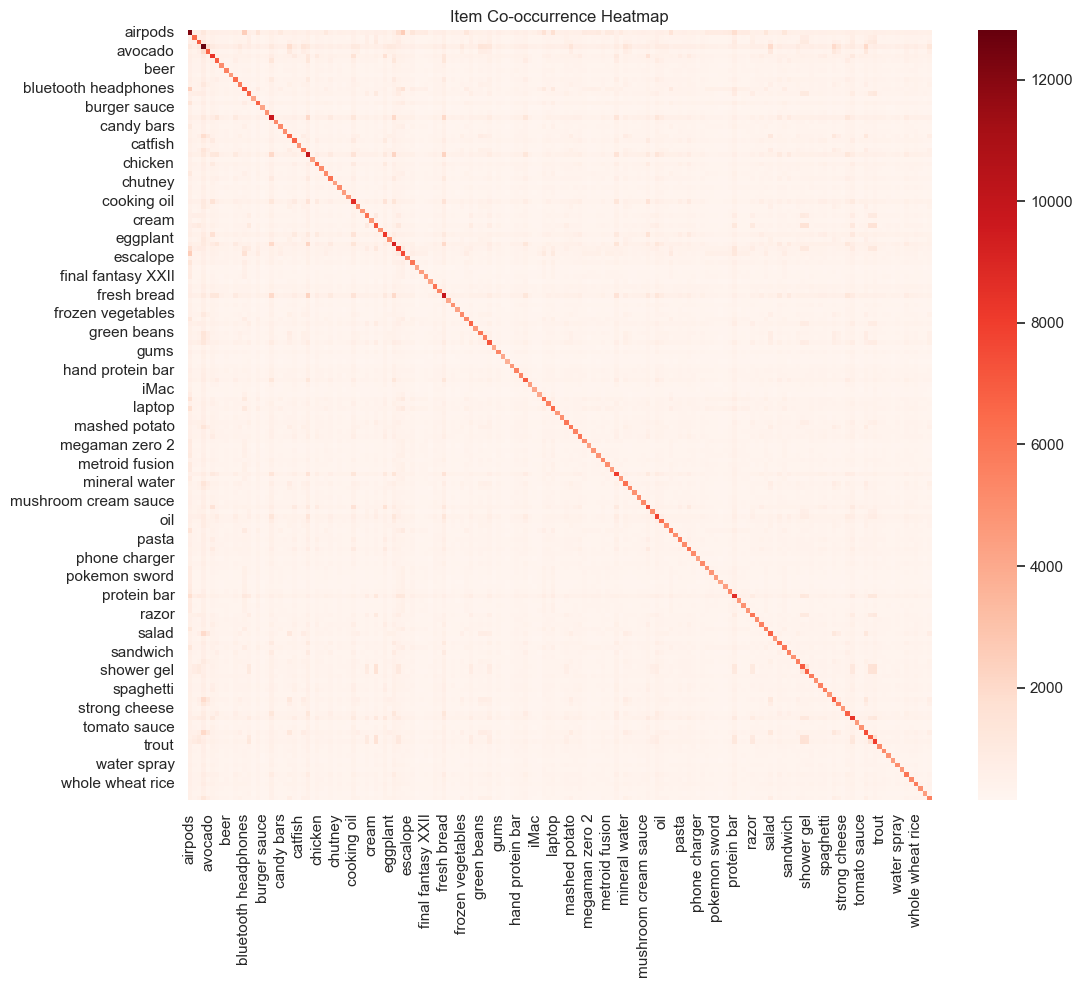

In [25]:
#Create a binary matrix (one-hot encoded items)
basket_matrix = basket_eda["list_of_goods"].explode().str.get_dummies().groupby(level=0).sum()

co_matrix = basket_matrix.T.dot(basket_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(co_matrix, cmap="Reds")
plt.title("Item Co-occurrence Heatmap")
plt.show()


As we can see no two items constantly appear on customer's baskets. However we can conclude that some items usually appear together (in the same basket), i.e. chicken and fresh bread. This will be usual to create some insights and produce marketing advertising later on.

<a id="3-missing"></a>
## **4. EDA Summary and Preprocessing Implications**

The customer_info dataset contains 33,038 customers, with a wide range of demographic and geographic attributes.

**Key insights**:
- The dataset is large and diverse, with customer IDs ranging broadly.
- Customer identifiers are mostly unique, indicating low duplication and good data quality.
- The geographic variables (latitude, longitude) show that:
    - Customers are highly concentrated in a small area (likely Lisbon region)
- Low variance suggests localized business operations
- The distribution of customers appears uniform, with no extreme outliers in numeric fields like location.

This dataset is well-suited for clustering, especially for:
- customer behavior segmentation based mainly on demographic, behavioral and spending-related variables.

**Preprocessing implications:**

- Convert `customer_birthdate` into `customer_age`.
- Drop non-informative identifiers such as `loyalty_card_number`.
- Handle impossible values in variables such as promotion percentage, typical hour, spending values and geographic coordinates.
- Impute missing numerical values where appropriate.
- Create customer-level features such as `total_children`, `years_tenure`, combined spending categories and spending-share variables.
- Flag multidimensional outliers using DBSCAN instead of removing customers.

**The customer_basket dataset captures detailed transactional behavior, providing insight into what customers purchase and how they shop.**

**Key insights**:
- Most transactions consist of small baskets, indicating typical day-to-day purchases, while a smaller number of large baskets suggest bulk or occasional high-volume buying.
- There is a clear variation in purchase frequency across customers, highlighting the presence of both frequent and infrequent buyers.
- The diversity of products suggests a broad product offering, potentially spanning multiple categories.

This dataset provides behavioral signals, making it highly suitable for:

- market basket analysis (association rules)
- identification of shopping patterns and preferences
- campaign design


**Preprocessing implications:**

- Preserve the basket dataset at transaction level rather than aggregating it by customer.
- Parse `list_of_goods` into Python lists.
- Create `basket_size` to describe the number of products per transaction.
- Use the processed basket dataset later for market basket analysis and association rules.